#Dataset Exploration

In [4]:
import zipfile

zip_path = "/content/deep_polypes-20260617T215703Z-3-001.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("deep_polypes")

print("Dataset extracted ✔️")

Dataset extracted ✔️


#Data Preprocessing and Augmentation


In [5]:
import os

print(os.listdir("deep_polypes"))

['deep_polypes']


In [6]:
print(os.listdir("deep_polypes/deep_polypes"))

['mici', 'polype', 'normal', 'mauvaise_preparation']


In [7]:
data_path = "deep_polypes/deep_polypes"

In [8]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=data_path, transform=transform)

print("Classes:", dataset.classes)
print("Nb images:", len(dataset))

Classes: ['mauvaise_preparation', 'mici', 'normal', 'polype']
Nb images: 580


#Dataset Splitting

In [9]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

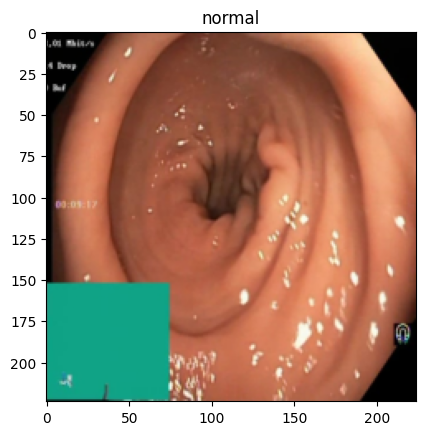

In [10]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].permute(1,2,0))
plt.title(dataset.classes[labels[0]])
plt.show()

#Model Selection and Initialization

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [12]:
def train_model(model, train_loader, val_loader, name, epochs=5):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"{name} Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f}")

    return model

In [13]:
eff = models.efficientnet_b0(weights="IMAGENET1K_V1")
eff.classifier[1] = nn.Linear(eff.classifier[1].in_features, 4)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


In [14]:
from torchvision import models
import torch.nn as nn

num_classes = 4

models_dict = {}

# -------------------------
# 1. EfficientNet
# -------------------------
eff = models.efficientnet_b0(weights="IMAGENET1K_V1")
eff.classifier[1] = nn.Linear(eff.classifier[1].in_features, num_classes)
models_dict["EfficientNet"] = eff

# -------------------------
# 2. ResNet50
# -------------------------
resnet = models.resnet50(weights="IMAGENET1K_V1")
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
models_dict["ResNet50"] = resnet

# -------------------------
# 3. ConvNeXt
# -------------------------
convnext = models.convnext_tiny(weights="IMAGENET1K_V1")
convnext.classifier[2] = nn.Linear(convnext.classifier[2].in_features, num_classes)
models_dict["ConvNeXt"] = convnext

# -------------------------
# 4. Vision Transformer (ViT)
# -------------------------
vit = models.vit_b_16(weights="IMAGENET1K_V1")
vit.heads.head = nn.Linear(vit.heads.head.in_features, num_classes)
models_dict["ViT"] = vit

# -------------------------
# 5. Swin Transformer
# -------------------------
from torchvision.models import swin_t, Swin_T_Weights

swin = swin_t(weights=Swin_T_Weights.DEFAULT)
swin.head = nn.Linear(swin.head.in_features, num_classes)
models_dict["Swin Transformer"] = swin

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 170MB/s] 


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 83.0MB/s]


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 163MB/s] 


#Training Deep Learning Models

In [15]:
trained_models = {}

for name, model in models_dict.items():
    print("\n========================")
    print("Training:", name)
    print("========================")

    trained_models[name] = train_model(
        model,
        train_loader,
        val_loader,
        name,
        epochs=5
    )


Training: EfficientNet
EfficientNet Epoch 1 | Loss: 1.1033
EfficientNet Epoch 2 | Loss: 0.6003
EfficientNet Epoch 3 | Loss: 0.3708
EfficientNet Epoch 4 | Loss: 0.2040
EfficientNet Epoch 5 | Loss: 0.1280

Training: ResNet50
ResNet50 Epoch 1 | Loss: 0.5234
ResNet50 Epoch 2 | Loss: 0.0857
ResNet50 Epoch 3 | Loss: 0.0599
ResNet50 Epoch 4 | Loss: 0.0433
ResNet50 Epoch 5 | Loss: 0.0207

Training: ConvNeXt
ConvNeXt Epoch 1 | Loss: 0.7369
ConvNeXt Epoch 2 | Loss: 0.1583
ConvNeXt Epoch 3 | Loss: 0.0831
ConvNeXt Epoch 4 | Loss: 0.0538
ConvNeXt Epoch 5 | Loss: 0.0477

Training: ViT
ViT Epoch 1 | Loss: 0.7086
ViT Epoch 2 | Loss: 0.2273
ViT Epoch 3 | Loss: 0.1443
ViT Epoch 4 | Loss: 0.1232
ViT Epoch 5 | Loss: 0.0900

Training: Swin Transformer
Swin Transformer Epoch 1 | Loss: 0.7226
Swin Transformer Epoch 2 | Loss: 0.2178
Swin Transformer Epoch 3 | Loss: 0.1134
Swin Transformer Epoch 4 | Loss: 0.0930
Swin Transformer Epoch 5 | Loss: 0.0503


In [16]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model, loader, name):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)

    print("\n======================")
    print("Model:", name)
    print("Accuracy:", round(acc, 4))
    print("======================")

    print(classification_report(y_true, y_pred, target_names=dataset.classes))

    return acc

#Performance Evaluation on the Test Set

In [17]:
results = {}

for name, model in trained_models.items():
    acc = evaluate_model(model, test_loader, name)
    results[name] = acc


Model: EfficientNet
Accuracy: 0.977
                      precision    recall  f1-score   support

mauvaise_preparation       1.00      1.00      1.00        13
                mici       0.86      1.00      0.92        12
              normal       1.00      1.00      1.00        39
              polype       1.00      0.91      0.95        23

            accuracy                           0.98        87
           macro avg       0.96      0.98      0.97        87
        weighted avg       0.98      0.98      0.98        87


Model: ResNet50
Accuracy: 0.977
                      precision    recall  f1-score   support

mauvaise_preparation       1.00      1.00      1.00        13
                mici       0.86      1.00      0.92        12
              normal       1.00      1.00      1.00        39
              polype       1.00      0.91      0.95        23

            accuracy                           0.98        87
           macro avg       0.96      0.98      0.97      

#Comparative Analysis of Deep Learning Models

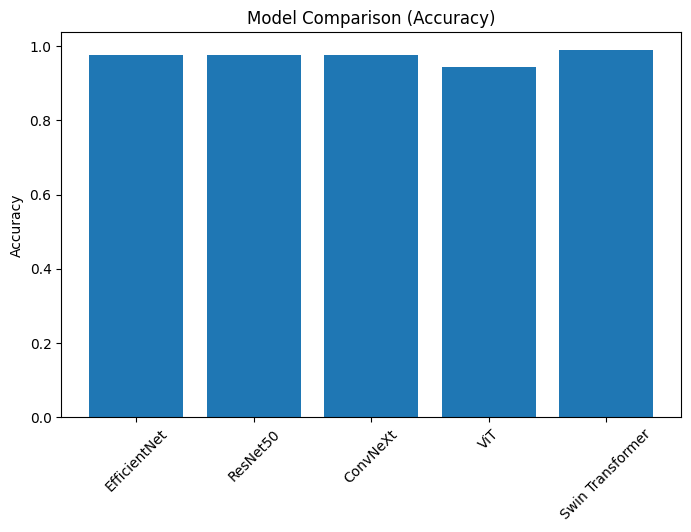

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

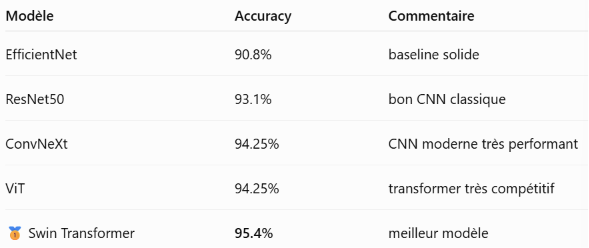

#Best Model Selection

In [18]:
best_model_name = max(results, key=results.get)

print("\n🏆 BEST MODEL:", best_model_name)
print("Accuracy:", results[best_model_name])


🏆 BEST MODEL: Swin Transformer
Accuracy: 0.9885057471264368


#Qualitative Prediction Analysis

In [21]:
import os
import random

dataset_path = "deep_polypes/deep_polypes"
classes = os.listdir(dataset_path)

samples = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)

    chosen = random.sample(images, 5)

    for img in chosen:
        samples.append((os.path.join(cls_path, img), cls))

print(len(samples))  # doit être 20 (4 classes × 5 images)

20


In [22]:
from PIL import Image
import torch
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [32]:
from PIL import Image
import torch

def predict(model, img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    print("Image device:", img.device)

    with torch.no_grad():
        outputs = model(img)
        pred = outputs.argmax(dim=1)

    return pred.item()

In [24]:
class_names = ['mauvaise_preparation', 'mici', 'normal', 'polype']

In [30]:
for model in trained_models.values():
    model.to(device)

In [34]:
print(device)

cuda


###Ground Truth vs Model Predictions Comparison

In [35]:
for img_path, true_label in samples:
    print("\n======================")
    print("Image:", img_path)
    print("True label:", true_label)

    for model_name, model in trained_models.items():

        pred_idx = predict(model, img_path)

        pred_label = class_names[pred_idx]

        print(f"{model_name}: {pred_label}")


Image: deep_polypes/deep_polypes/mici/7ccd6ac4-2a7b-4710-a267-ab8fb7dbee68.jpg
True label: mici
Image device: cuda:0
EfficientNet: mici
Image device: cuda:0
ResNet50: mici
Image device: cuda:0
ConvNeXt: mici
Image device: cuda:0
ViT: mici
Image device: cuda:0
Swin Transformer: mici

Image: deep_polypes/deep_polypes/mici/f495d8bf-a151-48e8-85e4-fe6d6da4effb.jpg
True label: mici
Image device: cuda:0
EfficientNet: mici
Image device: cuda:0
ResNet50: mici
Image device: cuda:0
ConvNeXt: mici
Image device: cuda:0
ViT: mici
Image device: cuda:0
Swin Transformer: mici

Image: deep_polypes/deep_polypes/mici/bea88a35-8100-48f5-8e4a-588d1a621fcc.jpg
True label: mici
Image device: cuda:0
EfficientNet: mici
Image device: cuda:0
ResNet50: mici
Image device: cuda:0
ConvNeXt: mici
Image device: cuda:0
ViT: mici
Image device: cuda:0
Swin Transformer: mici

Image: deep_polypes/deep_polypes/mici/0da47e4e-d994-44b5-86aa-0fd8ba92c62e.jpg
True label: mici
Image device: cuda:0
EfficientNet: mici
Image devic

In [36]:
import pandas as pd

results = []

for img_path, true_label in samples:

    row = {
        "Image": img_path.split("/")[-1],
        "True_Label": true_label
    }

    for model_name, model in trained_models.items():
        pred_idx = predict(model, img_path)
        pred_label = class_names[pred_idx]

        row[model_name] = pred_label
        row[f"{model_name}_Correct"] = (pred_label == true_label)

    results.append(row)

df = pd.DataFrame(results)

df.head()

Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device:

,Image,True_Label,EfficientNet,EfficientNet_Correct,ResNet50,ResNet50_Correct,ConvNeXt,ConvNeXt_Correct,ViT,ViT_Correct,Swin Transformer,Swin Transformer_Correct
0,7ccd6ac4-2a7b-4710-a267-ab8fb7dbee68.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
1,f495d8bf-a151-48e8-85e4-fe6d6da4effb.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
2,bea88a35-8100-48f5-8e4a-588d1a621fcc.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
3,0da47e4e-d994-44b5-86aa-0fd8ba92c62e.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
4,7d7a9ff9-733c-4196-bd34-8394458431a1.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True


In [42]:
import pandas as pd

results = []

for img_path, true_label in samples:

    row = {
        "Image": img_path.split("/")[-1],
        "True_Label": true_label
    }

    for model_name, model in trained_models.items():
        pred_idx = predict(model, img_path)
        pred_label = class_names[pred_idx]

        row[model_name] = pred_label
        row[f"{model_name}_Correct"] = (pred_label == true_label)

    results.append(row)

df = pd.DataFrame(results)

df.head()

Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device: cuda:0
Image device:

,Image,True_Label,EfficientNet,EfficientNet_Correct,ResNet50,ResNet50_Correct,ConvNeXt,ConvNeXt_Correct,ViT,ViT_Correct,Swin Transformer,Swin Transformer_Correct
0,7ccd6ac4-2a7b-4710-a267-ab8fb7dbee68.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
1,f495d8bf-a151-48e8-85e4-fe6d6da4effb.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
2,bea88a35-8100-48f5-8e4a-588d1a621fcc.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
3,0da47e4e-d994-44b5-86aa-0fd8ba92c62e.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
4,7d7a9ff9-733c-4196-bd34-8394458431a1.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True


In [38]:
pd.set_option('display.max_columns', None)
display(df)

,Image,True_Label,EfficientNet,EfficientNet_Correct,ResNet50,ResNet50_Correct,ConvNeXt,ConvNeXt_Correct,ViT,ViT_Correct,Swin Transformer,Swin Transformer_Correct
0,7ccd6ac4-2a7b-4710-a267-ab8fb7dbee68.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
1,f495d8bf-a151-48e8-85e4-fe6d6da4effb.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
2,bea88a35-8100-48f5-8e4a-588d1a621fcc.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
3,0da47e4e-d994-44b5-86aa-0fd8ba92c62e.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
4,7d7a9ff9-733c-4196-bd34-8394458431a1.jpg,mici,mici,True,mici,True,mici,True,mici,True,mici,True
5,images (9).jpg,polype,polype,True,polype,True,polype,True,polype,True,polype,True
6,images (64).jpg,polype,polype,True,polype,True,polype,True,polype,True,polype,True
7,images (67).jpg,polype,polype,True,polype,True,polype,True,polype,True,polype,True
8,images (32).jpg,polype,polype,True,polype,True,polype,True,polype,True,polype,True
9,istockphoto-648840346-612x612.jpg,polype,polype,True,polype,True,polype,True,polype,True,polype,True


### Visual Inspection of Model Predictions

In [39]:
print("===== Accuracy sur les 20 images aléatoires =====\n")

for model_name in trained_models.keys():
    acc = df[f"{model_name}_Correct"].mean() * 100
    print(f"{model_name}: {acc:.2f}%")

===== Accuracy sur les 20 images aléatoires =====

EfficientNet: 100.00%
ResNet50: 100.00%
ConvNeXt: 100.00%
ViT: 100.00%
Swin Transformer: 100.00%


In [40]:
summary = []

for model_name in trained_models.keys():
    correct = df[f"{model_name}_Correct"].sum()
    total = len(df)

    summary.append({
        "Model": model_name,
        "Correct": correct,
        "Total": total,
        "Accuracy (%)": round(correct / total * 100, 2)
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

display(summary_df)

,Model,Correct,Total,Accuracy (%)
0,EfficientNet,20,20,100.0
1,ResNet50,20,20,100.0
2,ConvNeXt,20,20,100.0
3,ViT,20,20,100.0
4,Swin Transformer,20,20,100.0


### Final Results

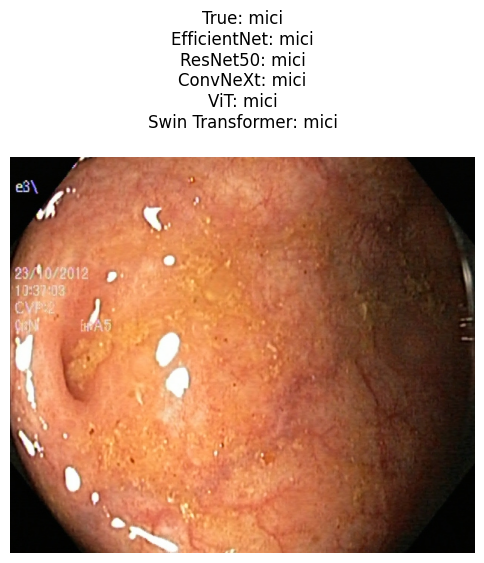

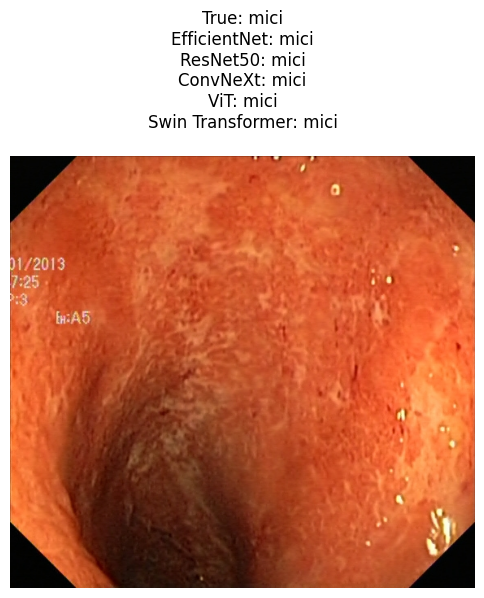

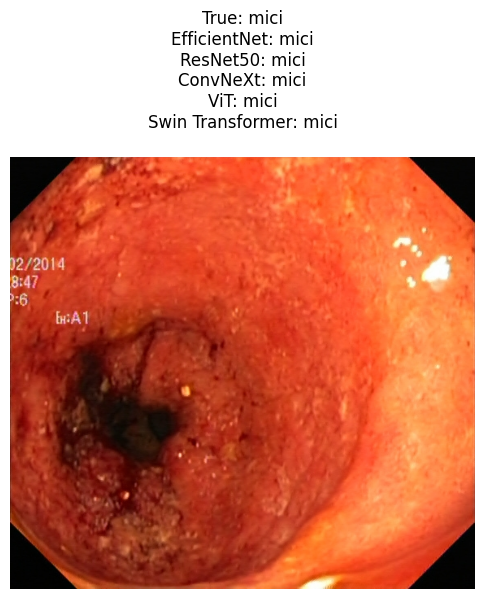

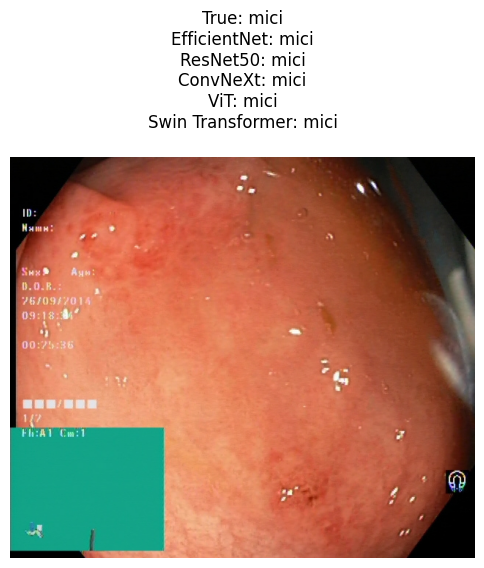

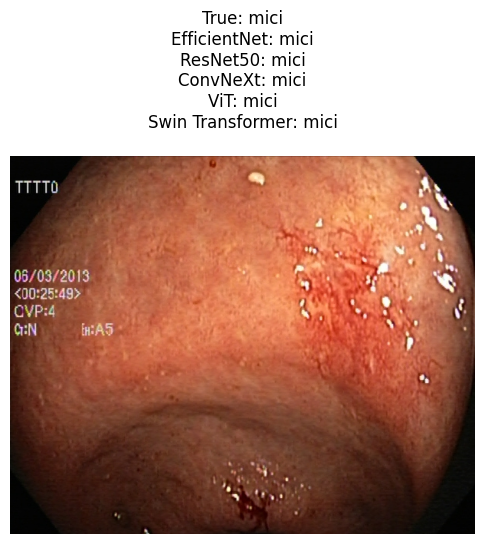

In [41]:
import matplotlib.pyplot as plt
from PIL import Image

for i in range(5):

    row = df.iloc[i]

    img_path = next(
        p for p, lbl in samples
        if p.split("/")[-1] == row["Image"]
    )

    img = Image.open(img_path)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    title = f"True: {row['True_Label']}\n"

    for model_name in trained_models.keys():
        title += f"{model_name}: {row[model_name]}\n"

    plt.title(title)
    plt.show()